# D400 Problem Set 3
###### Saturday 15th November 2025

We start by defining some function that we will use for the rest of the exercises:

In [2]:
import numpy as np
import matplotlib.pyplot as plt

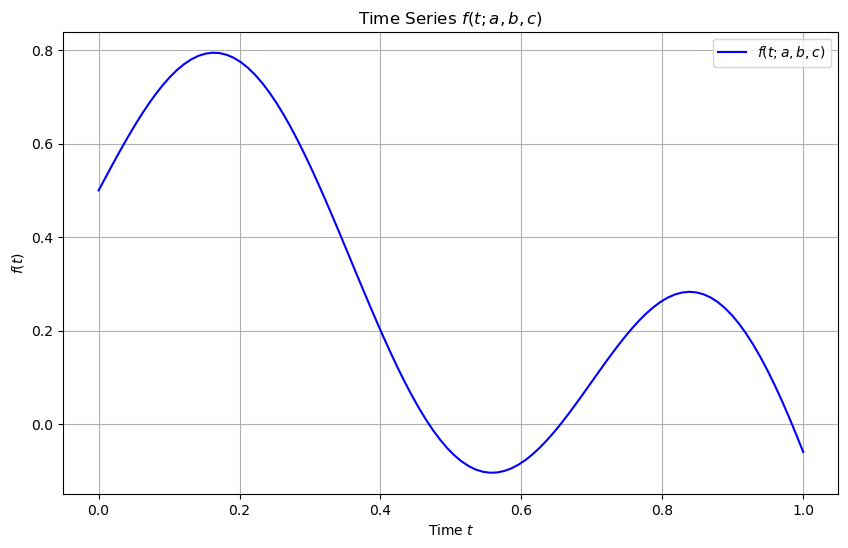

In [46]:
# define a function
def f(t, a, b, c):
    return np.sqrt(a) * np.exp(-b * t) * np.sin(c * t) + 0.5 * np.cos(2 * t)

# Example usage
# Define parameters
a = 0.1
b = -0.13
c = 9


# Define time range
t = np.linspace(0, 1, 100)  # time from 0 to 1 with 100 points

# Calculate f(t) for these parameters
f_values = f(t, a, b, c)

# Plot the function
plt.figure(figsize=(10, 6))
plt.plot(t, f_values, label=r'$f(t; a, b, c)$', color='blue')
plt.xlabel('Time $t$')
plt.ylabel(r'$f(t)$')
plt.title(r'Time Series $f(t; a, b, c)$')
plt.legend()
plt.grid(True)
plt.show()

To create a plot with interactive widgets we embed the plotting function within an `interactive` container along with a specification for each widget:

In [3]:
from ipywidgets import interactive
import ipywidgets as widgets

In [5]:
def plot_with_parameters(a, b, c):
    # Define time range
    t = np.linspace(0, 1, 100)

    # Calculate f(t) for these parameters
    f_values = f(t, a, b, c)

    # Plot the function
    plt.figure(figsize=(10, 6))
    plt.plot(t, f_values, label=r'$f(t; a, b, c)$', color='blue')
    plt.xlabel('Time $t$')
    plt.ylabel(r'$f(t)$')
    plt.title(r'Time Series $f(t; a, b, c)$')
    plt.legend()
    plt.grid(True)
    plt.show()


# Create interactive widget
interactive_plot = interactive(
    plot_with_parameters,
    a=widgets.FloatSlider(min=0, max=1, step=0.01, value=0.1),
    b=widgets.FloatSlider(min=-0.5, max=0.5, step=0.01, value=-0.13),
    c=widgets.FloatSlider(min=5, max=10, step=0.1, value=9)
)

display(interactive_plot)

interactive(children=(FloatSlider(value=0.1, description='a', max=1.0, step=0.01), FloatSlider(value=-0.13, de…

### Exercise 1: Initialising a 1D interpolator

Consider all parameter values (except *t*) are fixed and create an interpolator with respect to time .

You use the original grid for the interpolation.

In [10]:
from scipy.interpolate import interp1d


t = np.linspace(0, 1, num=100)  # define the time domain of the original function

x = t   # Holding all other variables fixed, allow only t to vary

y = f_values  # Function values at each time point `t` for a fixed `a`

# Create the interpolator function with respect to time `t`
# specify linear interpolation. Draw lines between the two closest points.
F_interp_t = interp1d(x, y, kind='linear', fill_value="extrapolate")

### Exercise 2: Using the interpolator

Now we use this interpolator function (which has been calibrated on x and y *[t and f_values]*) to interpolate y given x at any point on a finer time domain:

In [15]:
# Now you can use `F_interp_t` to interpolate the function at any time `t_new`

t_new = np.linspace(0, 1, num=1000) # Now take 1000 samples instead of 100 over the domain

f_value_at_t_new = F_interp_t(t_new)  # Interpolated value at t_new

### Exercise 3: Visualising the interpolated points

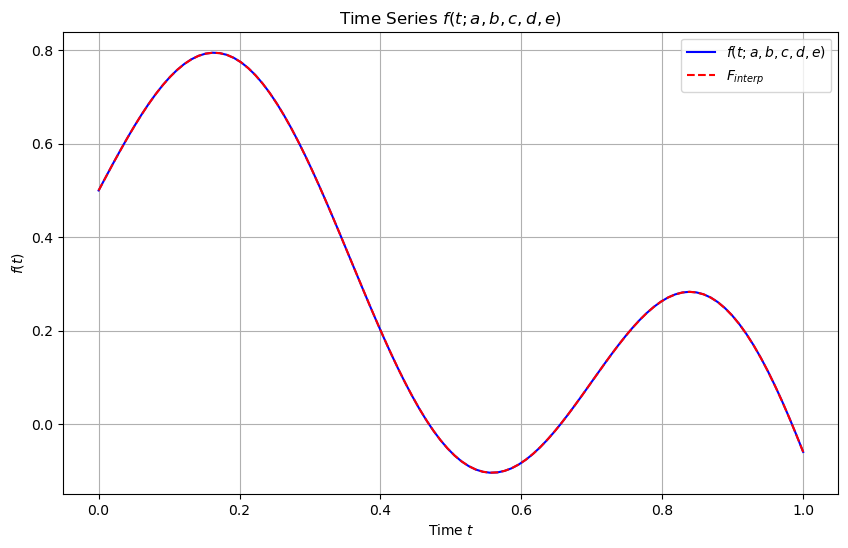

In [16]:
# Plot the function
plt.figure(figsize=(10, 6))
plt.plot(t, f_values, label=r'$f(t; a, b, c, d, e)$', color='blue') # plot the original function
plt.plot(t_new, f_value_at_t_new, label=r'$F_{interp}$', color='red',ls='--')   # plot interpolated values
plt.xlabel('Time $t$')
plt.ylabel(r'$f(t)$')
plt.title(r'Time Series $f(t; a, b, c, d, e)$')
plt.legend()
plt.grid(True)
plt.show()

### EXTRA: extrapolation using linear interpolation

In [17]:
t_extrapolate = np.linspace(0, 2, num=1000) # Expand the domain to t=2

f_value_extrapolate = F_interp_t(t_extrapolate)  # Interpolated value at t_new

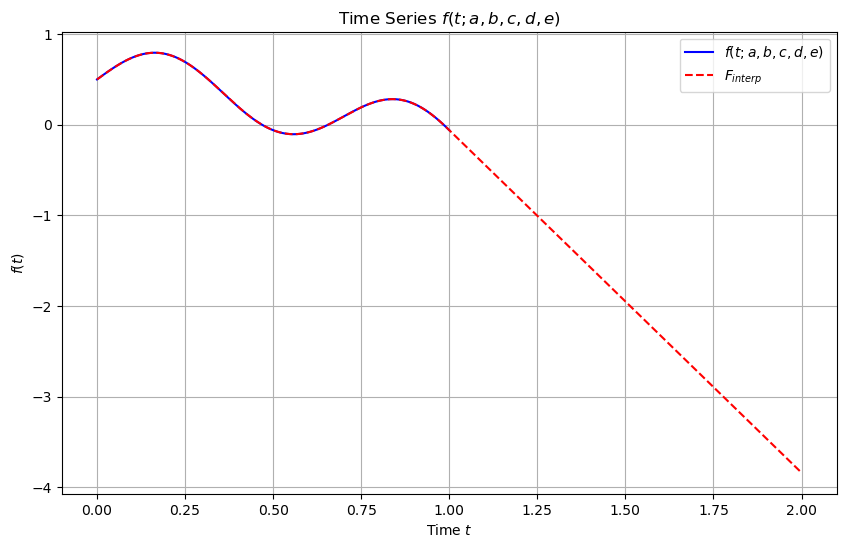

In [18]:
# Plot the function
plt.figure(figsize=(10, 6))
plt.plot(t, f_values, label=r'$f(t; a, b, c, d, e)$', color='blue') # plot the original function
plt.plot(t_extrapolate, f_value_extrapolate, label=r'$F_{interp}$', color='red',ls='--')   # plot interpolated values
plt.xlabel('Time $t$')
plt.ylabel(r'$f(t)$')
plt.title(r'Time Series $f(t; a, b, c, d, e)$')
plt.legend()
plt.grid(True)
plt.show()

We see that linear interpolation will just plot a straight line leading on from the final observed values. It is important to stay within the original domain for this kind of interpolation to remain useful.

### Exercise 4: Understaning linear interpolation

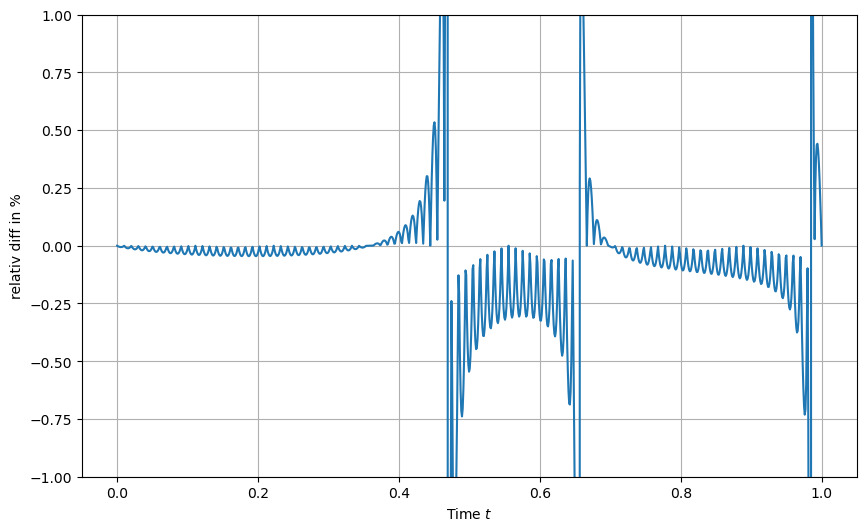

In [29]:
# Plot the function
plt.figure(figsize=(10, 6))

r = 100*(f_value_at_t_new-f(t_new, a, b, c))/f(t_new, a, b, c)
plt.plot(t_new, r)
plt.xlabel('Time $t$')
plt.ylabel(r'relativ diff in %')

plt.ylim(-1,1)
plt.grid(True)
plt.show()

This makes sense if we consider how the interpolated values are being computed. When the function is concave, the interpolated values will be below the true values. Conversely, when the function is concave the interpolated values will be above the actual values.

The magnitude of the error will be greater when the second derivative of the function is greater in magnitude. This is because the actual function is less linear, but we are trying to approximate it with a linear function.

This follows because the linearly interpolated values are weighted averages of the closest values eitherside of eachother.

#### EXTRA: Illustration of concavity/convexity

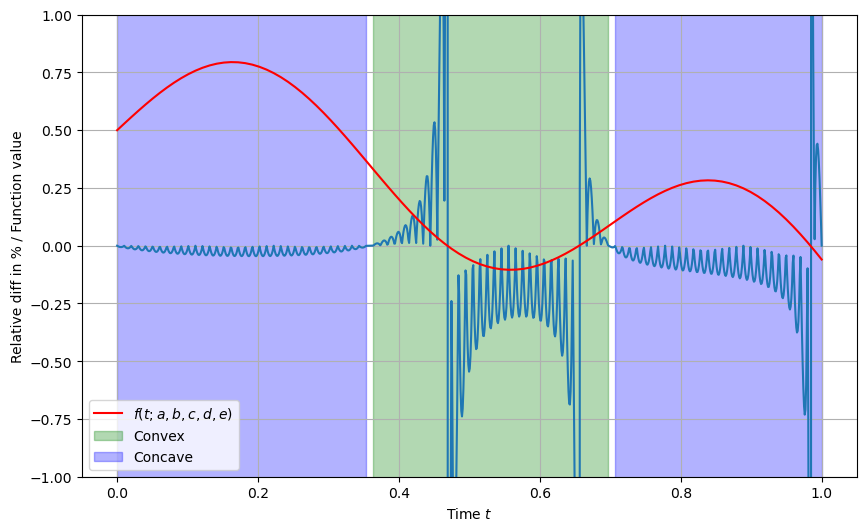

In [53]:
# Numerical second derivative
dt = t[1] - t[0]  # assuming uniform spacing
f_second = np.gradient(np.gradient(f_values, dt), dt)

# Determine convex (f'' > 0) and concave (f'' < 0)
convex = f_second > 0
concave = f_second < 0

plt.figure(figsize=(10, 6))

# plot the percentage error
r = 100*(f_value_at_t_new - f(t_new, a, b, c)) / f(t_new, a, b, c)
plt.plot(t_new, r)
plt.plot(t, f_values, label=r'$f(t; a, b, c, d, e)$', color='red')

# Shade convex regions
plt.fill_between(t, f_values.max()+1, f_values.min()-1, where=convex, color='green', alpha=0.3, label='Convex')

# Shade concave regions
plt.fill_between(t, f_values.max()+1, f_values.min()-1, where=concave, color='blue', alpha=0.3, label='Concave')

plt.xlabel('Time $t$')
plt.ylabel(r'Relative diff in % / Function value')
plt.ylim(-1, 1)
plt.grid(True)
plt.legend()
plt.show()

**Note that in this example the relative difference (error) is flipping sign around where the function passes zero and changes sign. This does not compromise the earlier claim about the direction of error as we are looking at percentage differences, not absolute differences**

- f is linear: perfect interpolation

- f is convex: positive error (interpolated curve above true function)

- f is concave: negative error (interpolated curve below true function)

- second derivative large: large error (large absolute relative difference)

- second derivative near zero: small error

#### Exercise 5: Generate samples of ***f()*** over values of ***a*** between 0 and 1

In [27]:
import pandas as pd

In [ ]:
# Generate 10 linearly spaced values of `a` from 0. to 1.0
a_values = np.linspace(0., 1.0, 10)

# Generate samples and store them in a DataFrame with labels from 1 to 10

# create a dictionary of the generated sequences along with the value of 'a' as a label
f_samples_labeled = {str(i+1): f(t, a, b, c) for i, a in enumerate(a_values)}

# convert the dictionary into a dataframe and show
f_samples_labeled_df = pd.DataFrame(f_samples_labeled, index=t)
f_samples_labeled_df

,1,2,3,4,5,6,7,8,9,10
0.000000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000
0.010101,0.499898,0.530199,0.542750,0.552381,0.560500,0.567653,0.574120,0.580067,0.585602,0.590801
0.020202,0.499592,0.560023,0.585055,0.604262,0.620454,0.634720,0.647618,0.659478,0.670517,0.680886
0.030303,0.499082,0.589223,0.626560,0.655210,0.679363,0.700643,0.719881,0.737572,0.754038,0.769504
0.040404,0.498368,0.617551,0.666918,0.704799,0.736734,0.764869,0.790305,0.813696,0.835468,0.855917
...,...,...,...,...,...,...,...,...,...,...
0.959596,-0.170695,0.097127,0.208063,0.293187,0.364950,0.428174,0.485333,0.537896,0.586821,0.632772
0.969697,-0.180154,0.062714,0.163313,0.240505,0.305581,0.362914,0.414747,0.462413,0.506779,0.548448
0.979798,-0.189539,0.026299,0.115702,0.184303,0.242137,0.293089,0.339154,0.381515,0.420943,0.457975
0.989899,-0.198847,-0.011895,0.065544,0.124964,0.175058,0.219191,0.259091,0.295782,0.329934,0.362010


<Axes: >

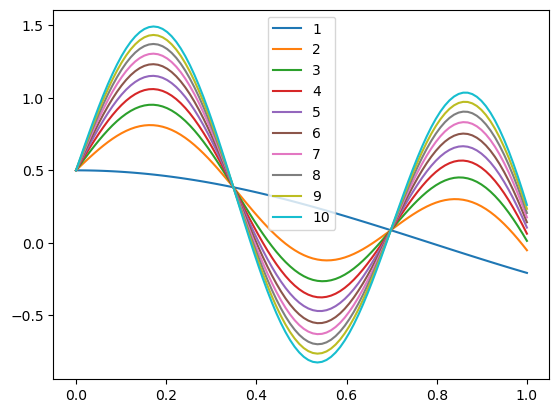

In [ ]:
# plot f() at different values of 'a'
f_samples_labeled_df.plot(legend=True)

#### Exercise 6: 2D interpolation (a and t can vary)

In [32]:
from scipy.interpolate import RegularGridInterpolator

In [47]:
t = np.linspace(0, 1, num=100)

# Convert the DataFrame to a 2D NumPy array with shape (len(t), len(a_values))
f_values_matrix = f_samples_labeled_df.values  # Shape: (100, 10) in this example

# Create an interpolator across `a` and `t`
interpolator = RegularGridInterpolator((t, a_values), f_values_matrix, method="linear", bounds_error=False, fill_value=None)

# Define a function that interpolates over a new `a` value
def interpolate_f_over_a(new_a):
    # Create a mesh of (time, new_a) points
    query_points = np.array([(time, new_a) for time in t])

    # Interpolate at all time points for the given new `a`
    return interpolator(query_points)

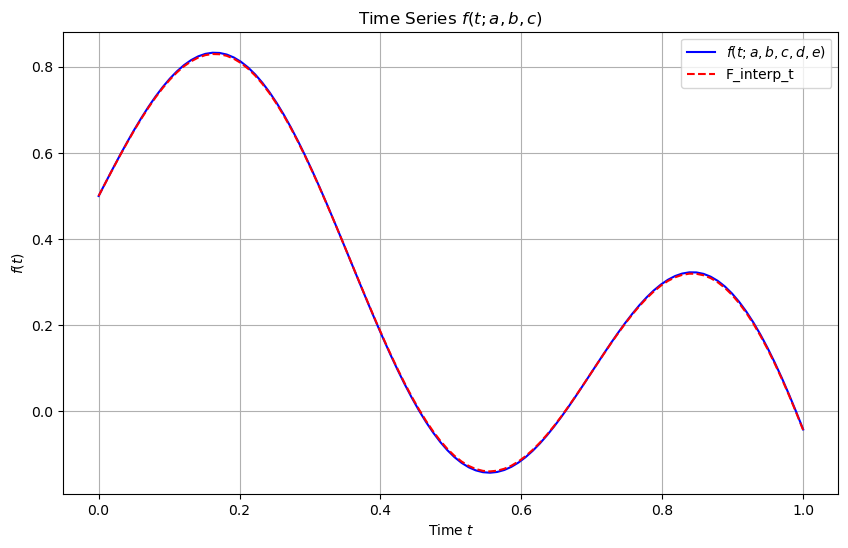

In [49]:
ap = 0.125  # interpolate over a=0.125 and t(0,1, 100)

# Plot the function
plt.figure(figsize=(10, 6))
plt.plot(t, f(t, ap, b, c), label=r'$f(t; a, b, c, d, e)$', color='blue')
plt.plot(t, interpolate_f_over_a(ap), label=r'F_interp_t', color='red',ls='--')
plt.xlabel('Time $t$')
plt.ylabel(r'$f(t)$')
plt.title(r'Time Series $f(t; a, b, c)$')
plt.legend()
plt.grid(True)
plt.show()

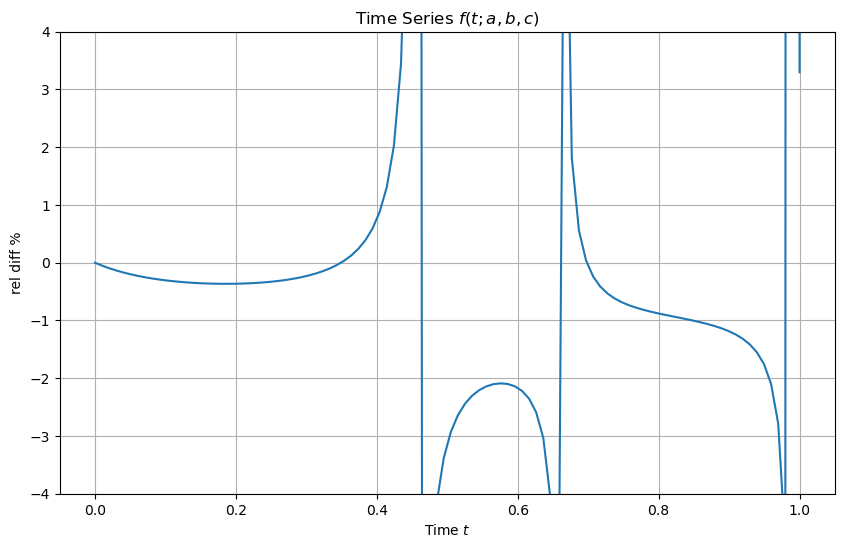

In [50]:
# Plot the function
plt.figure(figsize=(10, 6))
r = 100*(interpolate_f_over_a(ap)/f(t, ap, b, c) - 1 )
plt.plot(t,r)
plt.xlabel('Time $t$')
plt.ylabel(r'rel diff %')
plt.title(r'Time Series $f(t; a, b, c)$')
plt.grid(True)
plt.ylim(-4.,4.)
plt.show()

#### Exercise 7: Interactive Version

In [ ]:
from ipywidgets import interact, FloatSlider
import ipywidgets as widgets

# Define the slider function to update the plot
def plot_interpolated_relative_difference(ap):
    # Calculate the relative difference
    r = 100 * (interpolate_f_over_a(ap) / f(t, ap, b, c) - 1.)

    # Plot the relative difference
    plt.figure(figsize=(10, 6))
    plt.plot(t, r)
    plt.xlabel('Time $t$')
    plt.ylabel(r'Relative Difference %')
    plt.title(r'Time Series $f(t; a, b, c)$')
    plt.ylim(-10,10)
    plt.grid(True)
    plt.show()

# Define the slider for `ap`
ap_slider = FloatSlider(value=0.145, min=0., max=1.0, step=0.001, description='ap')

# Use `interact` to create the interactive plot
interact(plot_interpolated_relative_difference, ap=ap_slider)

interactive(children=(FloatSlider(value=0.145, description='ap', max=1.0, step=0.001), Output()), _dom_classes…

<function __main__.plot_interpolated_relative_difference(ap)>

#### EXTRA: All in a single plot

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

# Parameters
b = -0.13
c = 9

def plot_interpolated_relative_difference(ap):
    # Original function for chosen `ap`
    f_vals = f(t, ap, b, c)
    
    # Relative difference in percent
    r = 100 * (interpolate_f_over_a(ap) / f(t, ap, b, c) - 1.)
    
    # Numerical second derivative to determine convexity/concavity
    dt = t[1] - t[0]
    f_second = np.gradient(np.gradient(f_vals, dt), dt)
    convex = f_second > 0
    concave = f_second < 0
    
    # Initialise plot figure
    plt.figure(figsize=(12, 6))
    
    # Plot original function
    plt.plot(t, f_vals, label='Original $f(t; a, b, c)$', color='red')
    
    # Plot interpolated relative difference
    plt.plot(t, r, label='Relative Difference (%)', color='blue')
    
    # Shade convex regions
    plt.fill_between(t, f_vals.min()-10, f_vals.max()+10, where=convex, color='green', alpha=0.3, label='Convex')
    
    # Shade concave regions
    plt.fill_between(t, f_vals.min()-10, f_vals.max()+10, where=concave, color='blue', alpha=0.3, label='Concave')
    
    plt.xlabel('Time $t$')
    plt.ylabel('Function / Relative Difference')
    plt.title(f'Time Series $f(t; a={ap:.3f}, b={b}, c={c})$')
    plt.ylim(-10,10)
    plt.grid(True)
    plt.legend()
    plt.show()

# Slider for `ap`
ap_slider = FloatSlider(value=0.145, min=0.0, max=1.0, step=0.001, description='ap')

# Interactive plot
interact(plot_interpolated_relative_difference, ap=ap_slider)


interactive(children=(FloatSlider(value=0.145, description='ap', max=1.0, step=0.001), Output()), _dom_classes…

<function __main__.plot_interpolated_relative_difference(ap)>

This graph makes sense when we carry over the same intuition from the 1-dimensional linear interpolation.

- Linearly interpolating a concave function will result in a negative absoute error, and vice versa.

- The error will be greater where the function is less linear (second derivative is larger in absolute value)

**I'm not sure why the error seems to reduce to zero at all points when:**

- a = 0.56

- a = 1